In [2]:
import numpy as np
import h5py
import os
import time

from matplotlib import pyplot as plt
from simulation import run_simulation, run_tdi
from qtransform import generate_qscan
from h5file_helpers import create_dataset, append_gw_sample
from config import *

import warnings
warnings.filterwarnings("ignore")

In [25]:
pipe = {'t0':10368000, 'dt':0.25, 'size':10*3600/0.25, 'gw_beta':0, 'gw_lambda':np.pi/7}

glitches = [{'type':'OneSidedDoubleExpGlitch', 't_inj': 0,
             'level':0, 't_rise':1, 't_fall':1, 'inj_point':'readout_tmi_carrier_12'}]

In [56]:
res = 512
H, W = res, res
if os.path.exists(gw_dataset_path):
    os.remove(gw_dataset_path)
    
h5file = create_dataset(gw_dataset_path, resolution=(H, W))


In [68]:
mass_arr = [1e4]
q_arr = [1]

start = time.time()
iterations = len(mass_arr) * len(q_arr)
count = 0
for m in mass_arr:
    for q in q_arr:
        count += 1
        print(f"Generating sample {count} of {iterations}: m1={m}, m2={m*q}")

        iter_start = time.time()
        gws = [{'type':'BinaryInspiralGW', 'm1':m, 'm2':m*q, 'd':1e3, 'spin1':0.0, 'spin2':0.0,
        't_inj':7*3600, 'domain':'freq'}]

        run_simulation(gws, glitches, pipe,
                    gw_path, glitch_path, orbits_path, simulation_path, disable_noise=False,)
        tdi_dict = run_tdi(simulation_path, pipe)

        event = gws[0]
        t_arr, f_arr, QT = generate_qscan(tdi_dict, Q=15, channel='X', pipe=pipe, event=event, resolution=res, 
                        frange=(1e-3, 1e-1), trange=(-3.5, 2.5))
        append_gw_sample(h5file, QT, event['m1'], event['m2'], event['d'])
        iter_end = time.time()
        print(f"Time taken: {iter_end - iter_start} seconds\n")
end = time.time()
print(f"Total time taken: {end - start} seconds")

You are using an orbit file in a version that might not be fully supported


Generating sample 1 of 1: m1=10000.0, m2=10000.0


You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported


Time taken: 14.103097200393677 seconds

Total time taken: 14.103563070297241 seconds


In [10]:
with h5py.File(gw_dataset_path, "r") as h5:
    QT_array = h5["QT"][:]       # shape (N, 512, 512)
    m1_array = h5["m1"][:]
    m2_array = h5["m2"][:]
    d_array = h5["d"][:]
    spin_array = h5["spin"][:]

In [11]:
len(QT_array)

10

In [12]:
m1_array/1e6

array([10.,  1.,  1.,  1.,  1.,  1., 10., 10., 10., 10.],
      dtype=float32)

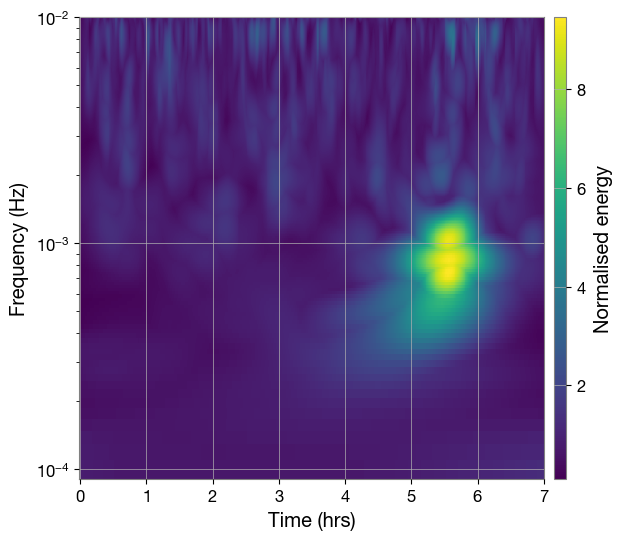

In [13]:
f_arr = np.linspace(1e-4, 1e-2, 512, endpoint=True)
t_arr = np.linspace(0, 7, 512, endpoint=True)

fig, axes = plt.subplots(1, 1, sharey=True, figsize=(6,6))

axes.pcolormesh(t_arr, f_arr, QT_array[-1], cmap='viridis')
axes.colorbar(label='Normalised energy')
axes.set_xlabel('Time (hrs)')
axes.set_ylabel('Frequency (Hz)')
axes.set_yscale('log')
plt.show()

In [13]:
QT_array.shape

(2, 512, 512)